# Waste Type Identification — Esperimento 2: Gestione dello Sbilanciamento

Questo notebook ripete **esattamente** la ricetta della baseline (stesso split, stessa
ResNet18, stessi iperparametri, stesso scheduler, stesse epoche, **nessuna augmentation**)
cambiando **una sola variabile**: il meccanismo di ribilanciamento delle classi.

Per eseguire i due esperimenti basta cambiare `REBALANCE` in cima e rilanciare: tutto il
resto resta garantito identico alla baseline, quindi qualunque differenza di risultato è
attribuibile **solo** al ribilanciamento.

> La valutazione OOD su RealWaste **non** è in questo notebook: si riusa il notebook
> `test_crossdataset_realwaste.ipynb` gia validato, puntandolo ai pesi salvati qui.

## 1. Configurazione

**Cambiare solo `REBALANCE`** per passare da un esperimento all'altro. Gli iperparametri
sotto sono identici alla baseline (`03_train_baseline`).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

REBALANCE = 'sampler'                                                           # 'weighted_loss' oppure 'sampler'

# Percorsi
BASE = Path('/content/drive/MyDrive/2026_MLinf_gr41/Waste-Project')
DRIVE_DATASET_DIR = BASE / 'dataset'                                            # sorgente del dataset su Drive
DATASET_DIR = Path('/content/dataset_local')                                    # copia locale
SPLIT_CSV = BASE / 'splits' / 'split.csv'                                       # stesso split 80/20 della baseline
MODELS_DIR = BASE / 'models'
RESULTS_DIR = BASE / 'results'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Iperparametri identici alla Baseline
IMG_SIZE = 224
BATCH_SIZE = 64
NUM_EPOCHS = 15
LR = 0.01
MOMENTUM = 0.9
WEIGHT_DECAY = 1e-4
NUM_CLASSES = 8
SEED = 1234

assert REBALANCE in ('weighted_loss', 'sampler'), \
    "REBALANCE deve essere 'weighted_loss' o 'sampler'"
TAG = f'imbalance_{REBALANCE}'                                                  # suffisso per non sovrascrivere i risultati tra i run
print('Esperimento:', TAG)

Mounted at /content/drive
Esperimento: imbalance_sampler


In [ ]:
import random, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image
from tqdm.auto import tqdm
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, recall_score
import matplotlib.pyplot as plt

# Riproducibilità (stesso seed della baseline)
def set_seed(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

CLASS_NAMES = ['battery','clothing','glass','metal','organic','papery','plastic','undifferentiated']
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

Device: cuda


## 2. Copia del dataset in locale

In [ ]:
import shutil
if not DATASET_DIR.exists():
    print('Copio il dataset in locale, attendi qualche minuto...')
    t0 = time.time()
    shutil.copytree(DRIVE_DATASET_DIR, DATASET_DIR)
    print(f'Copia completata in {time.time() - t0:.0f}s')
else:
    print('Copia locale gia presente:', DATASET_DIR)

Copio il dataset in locale, attendi qualche minuto...
Copia completata in 445s


## 3. Preprocessing (identico alla baseline, NESSUNA augmentation)

Per isolare il ribilanciamento come unica variabile rispetto alla baseline, **non**
applichiamo augmentation: la transform di training coincide con quella di validation
(`Resize((224,224))` senza crop + normalizzazione ImageNet). Cosi l'unica differenza
rispetto alla baseline è il meccanismo di ribilanciamento, non l'augmentation.

In [ ]:
# Train e Val condividono la stessa transform (come nella baseline: nessuna augmentation)
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
train_transform = eval_transform
val_transform = eval_transform

## 4. Dataset, conteggi per classe e meccanismo di ribilanciamento


In [ ]:
class WasteDataset(Dataset):
    def __init__(self, df, root, transform):
        self.df = df.reset_index(drop=True)
        self.root = Path(root)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(self.root / row['filepath']).convert('RGB')
        return self.transform(img), int(row['label'])

df = pd.read_csv(SPLIT_CSV)
df_train = df[df['split'] == 'train'].copy()
df_val = df[df['split'] == 'val'].copy()
print(f'Train: {len(df_train)} | Val: {len(df_val)}')

train_ds = WasteDataset(df_train, DATASET_DIR, train_transform)
val_ds = WasteDataset(df_val, DATASET_DIR, val_transform)

# Conteggi per classe sul training (ordinati per label 0..7)
counts = df_train['label'].value_counts().sort_index()
counts = counts.reindex(range(NUM_CLASSES), fill_value=0)
print('\nCampioni di training per classe:')
for c in range(NUM_CLASSES):
    print(f'  {c} {CLASS_NAMES[c]:<16} {int(counts[c])}')
imb_ratio = counts.max() / counts.min()
print(f'  Rapporto di sbilanciamento (max/min): {imb_ratio:.1f}x')

# Unica variabile: costruzione del meccanismo di ribilanciamento
class_weights = None                                                            # per la weighted loss
if REBALANCE == 'weighted_loss':
    counts_t = torch.tensor(counts.values, dtype=torch.float)
    class_weights = counts_t.sum() / (NUM_CLASSES * counts_t)
    class_weights = class_weights.to(device)
    print('\nPesi di classe (weighted CE):')
    for c in range(NUM_CLASSES):
        print(f'  {CLASS_NAMES[c]:<16} {class_weights[c].item():.3f}')
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True)

elif REBALANCE == 'sampler':
    inv_freq = (1.0 / counts).to_dict()
    sample_w = df_train['label'].map(inv_freq).values
    sample_w = torch.as_tensor(sample_w, dtype=torch.double)
    sampler = WeightedRandomSampler(sample_w, num_samples=len(df_train), replacement=True)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                              num_workers=2, pin_memory=True)
    print('\nWeightedRandomSampler attivo: ogni batch e (in media) bilanciato.')

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

Train: 12413 | Val: 3102

Campioni di training per classe:
  0 battery          756
  1 clothing         5842
  2 glass            1609
  3 metal            615
  4 organic          788
  5 papery           1553
  6 plastic          692
  7 undifferentiated 558
  Rapporto di sbilanciamento (max/min): 10.5x

WeightedRandomSampler attivo: ogni batch e (in media) bilanciato.


## 5. Modello

Identico alla baseline: ResNet18 pre-addestrata su ImageNet, con l'ultimo layer
fully-connected sostituito da uno lineare a 8 output. L'unica differenza nella loss è il
peso di classe, attivo solo nel run `weighted_loss`.

In [ ]:
def build_model():
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    return m

model = build_model().to(device)

# La sola differenza nella loss è il peso di classe (None nel run 'sampler')
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.SGD(model.parameters(), lr=LR,
                            momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 186MB/s]


## 6. Training

Loop standard, identico alla baseline. A ogni epoca valutiamo la Balanced Accuracy sulla
validation e teniamo il checkpoint migliore. Salviamo i
pesi con il suffisso del run (`resnet18_imbalance_weighted_loss.pth` /
`resnet18_imbalance_sampler.pth`) per non sovrascrivere i run precedenti.

In [ ]:
def evaluate(model, loader):
    model.eval()
    all_pred, all_true = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            logits = model(x)
            all_pred.append(logits.argmax(1).cpu())
            all_true.append(y)
    y_pred = torch.cat(all_pred).numpy()
    y_true = torch.cat(all_true).numpy()
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    return bal_acc, y_true, y_pred

history = {'train_loss': [], 'val_balacc': []}
best_balacc = -1.0
best_path = MODELS_DIR / f'resnet18_{TAG}.pth'

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    running = 0.0
    for x, y in tqdm(train_loader, desc=f'epoch {epoch}/{NUM_EPOCHS} [{TAG}]'):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        running += loss.item() * x.size(0)
    scheduler.step()

    train_loss = running / len(train_ds)
    val_balacc, _, _ = evaluate(model, val_loader)
    history['train_loss'].append(train_loss)
    history['val_balacc'].append(val_balacc)
    print(f'  loss={train_loss:.4f}  val_balAcc={val_balacc:.4f}')

    if val_balacc > best_balacc:
        best_balacc = val_balacc
        torch.save(model.state_dict(), best_path)
        print(f'  -> nuovo best ({best_balacc:.4f}) salvato in {best_path.name}')

print(f'\nMiglior val Balanced Accuracy [{TAG}]: {best_balacc:.4f}')

epoch 1/15 [imbalance_sampler]:   0%|          | 0/194 [00:00<?, ?it/s]

  loss=0.2944  val_balAcc=0.9136
  -> nuovo best (0.9136) salvato in resnet18_imbalance_sampler.pth


epoch 2/15 [imbalance_sampler]:   0%|          | 0/194 [00:00<?, ?it/s]

  loss=0.0922  val_balAcc=0.9367
  -> nuovo best (0.9367) salvato in resnet18_imbalance_sampler.pth


epoch 3/15 [imbalance_sampler]:   0%|          | 0/194 [00:00<?, ?it/s]

...

  loss=0.0018  val_balAcc=0.9619
  -> nuovo best (0.9619) salvato in resnet18_imbalance_sampler.pth


epoch 14/15 [imbalance_sampler]:   0%|          | 0/194 [00:00<?, ?it/s]

  loss=0.0012  val_balAcc=0.9592


epoch 15/15 [imbalance_sampler]:   0%|          | 0/194 [00:00<?, ?it/s]

  loss=0.0026  val_balAcc=0.9612

Miglior val Balanced Accuracy [imbalance_sampler]: 0.9619


## 7. Curve di training

Loss di train e Balanced Accuracy di validation per epoca.

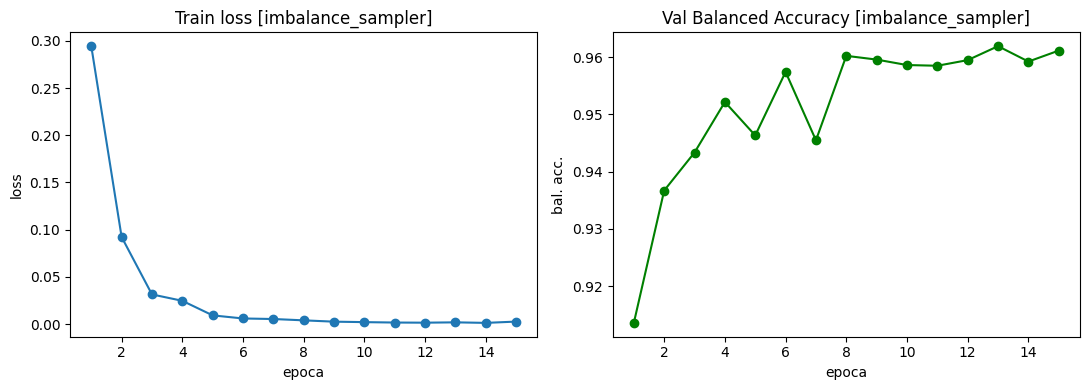

Salvato: /content/drive/MyDrive/2026_MLinf_gr41/Waste-Project/results/curves_imbalance_sampler.png


In [ ]:
epochs = range(1, NUM_EPOCHS + 1)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(epochs, history['train_loss'], marker='o'); ax[0].set_title(f'Train loss [{TAG}]')
ax[0].set_xlabel('epoca'); ax[0].set_ylabel('loss')
ax[1].plot(epochs, history['val_balacc'], marker='o', color='green')
ax[1].set_title(f'Val Balanced Accuracy [{TAG}]')
ax[1].set_xlabel('epoca'); ax[1].set_ylabel('bal. acc.')
plt.tight_layout()
curves_path = RESULTS_DIR / f'curves_{TAG}.png'
plt.savefig(curves_path, dpi=120, bbox_inches='tight')
plt.show()
print('Salvato:', curves_path)

## 8. Analisi in-distribution: TPR per classe + matrice di confusione

Ricarichiamo il best checkpoint e calcoliamo le TPR (recall) per classe sulla validation,
poi salviamo la matrice di confusione normalizzata per riga. Queste TPR servono per il
confronto in-distribution con la baseline; il confronto OOD si fa nel notebook RealWaste.

[imbalance_sampler] Val Balanced Accuracy: 0.9619

TPR per classe (in-distribution):
           class  label  tpr_val
         battery      0 0.973545
        clothing      1 0.997260
           glass      2 0.962687
           metal      3 0.941558
         organic      4 0.984772
          papery      5 0.974227
         plastic      6 0.890173
undifferentiated      7 0.971223
Salvato: /content/drive/MyDrive/2026_MLinf_gr41/Waste-Project/results/per_class_tpr_imbalance_sampler.csv


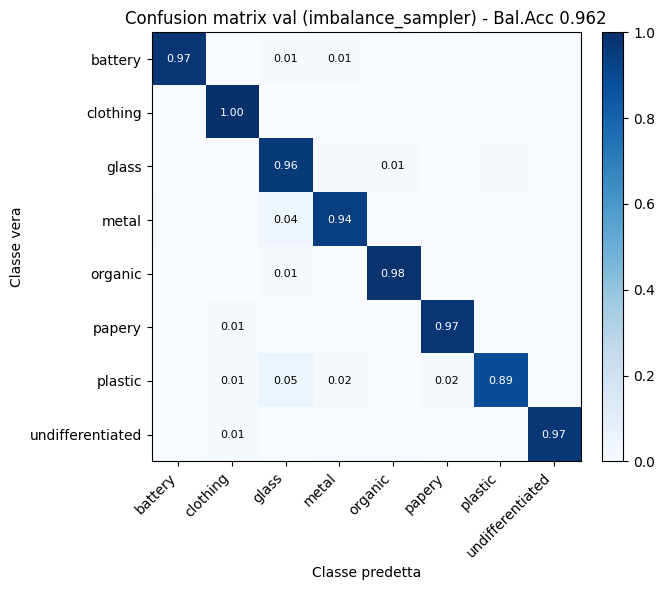

Salvato: /content/drive/MyDrive/2026_MLinf_gr41/Waste-Project/results/confusion_val_imbalance_sampler.png


In [ ]:
model.load_state_dict(torch.load(best_path, map_location=device))
val_balacc, y_true, y_pred = evaluate(model, val_loader)
print(f'[{TAG}] Val Balanced Accuracy: {val_balacc:.4f}')

# TPR (recall) per classe
tpr = recall_score(y_true, y_pred, labels=list(range(NUM_CLASSES)), average=None, zero_division=0)
tpr_df = pd.DataFrame({'class': CLASS_NAMES, 'label': range(NUM_CLASSES), 'tpr_val': tpr})
tpr_csv = RESULTS_DIR / f'per_class_tpr_{TAG}.csv'
tpr_df.to_csv(tpr_csv, index=False)
print('\nTPR per classe (in-distribution):')
print(tpr_df.to_string(index=False))
print('Salvato:', tpr_csv)

# Matrice di confusione normalizzata per riga
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)), normalize='true')
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, vmin=0, vmax=1, cmap='Blues')
ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Classe predetta'); ax.set_ylabel('Classe vera')
ax.set_title(f'Confusion matrix val ({TAG}) - Bal.Acc {val_balacc:.3f}')
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if cm[i, j] >= 0.01:
            ax.text(j, i, f'{cm[i, j]:.2f}', ha='center', va='center',
                    color='white' if cm[i, j] > 0.5 else 'black', fontsize=8)
fig.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
cm_path = RESULTS_DIR / f'confusion_val_{TAG}.png'
plt.savefig(cm_path, dpi=120, bbox_inches='tight')
plt.show()
print('Salvato:', cm_path)